In [3]:
import pandas as pd
import matplotlib
import numpy as np

In [4]:
df = pd.read_csv("deliveries_.csv")

In [8]:
#Q1
print(df.groupby("batting_team")["total_runs"].sum().reset_index(name = "Total runs(including byes and penalties)").rename(columns={"batting_team":"Team"}).to_string(index = False,col_space = 20))

                       Team  Total runs(including byes and penalties)
        Chennai Super Kings                                     26418
            Deccan Chargers                                     11463
             Delhi Capitals                                      2630
           Delhi Daredevils                                     24388
              Gujarat Lions                                      4862
            Kings XI Punjab                                     27893
       Kochi Tuskers Kerala                                      1901
      Kolkata Knight Riders                                     27419
             Mumbai Indians                                     29809
              Pune Warriors                                      6358
           Rajasthan Royals                                     22431
     Rising Pune Supergiant                                      2470
    Rising Pune Supergiants                                      2063
Royal Challengers Ba

In [20]:
#Q2
batsman_runs_list = df.groupby("batsman")["batsman_runs"].sum().reset_index(name="Total Runs scored by batsman").rename(columns={"batsman":"Player"})
top_batsman_runs_list = batsman_runs_list.nlargest(10,"Total Runs scored by batsman",keep = "all").to_string(index=False,col_space=35)
print(top_batsman_runs_list)

                             Player        Total Runs scored by batsman
                            V Kohli                                5434
                           SK Raina                                5415
                          RG Sharma                                4914
                          DA Warner                                4741
                           S Dhawan                                4632
                           CH Gayle                                4560
                           MS Dhoni                                4477
                         RV Uthappa                                4446
                     AB de Villiers                                4428
                          G Gambhir                                4223


In [25]:
#Q3
print(df.groupby("bowler").size().reset_index(name="Total balls bowled").rename(columns={"bowler":"Player"}).nlargest(10,"Total balls bowled",keep="all").to_string(index=False, col_space=30 ))

                        Player             Total balls bowled
               Harbhajan Singh                           3451
                      A Mishra                           3172
                     PP Chawla                           3157
                      R Ashwin                           3016
                    SL Malinga                           2974
                      DJ Bravo                           2711
                       B Kumar                           2707
                       P Kumar                           2637
                      UT Yadav                           2605
                     SP Narine                           2600


In [41]:
#Q4
only_fours_list = df[df["batsman_runs"]==4]
total_fours_batsman_list = only_fours_list.groupby("batsman").size().reset_index(name="Total number of fours hit").rename(columns={"batsman":"Player"})
most_fours = total_fours_batsman_list.nlargest(1,"Total number of fours hit",keep="all")["Total number of fours hit"].to_string(index = False)
most_fours_player = total_fours_batsman_list.nlargest(1,"Total number of fours hit",keep="all")["Player"].to_string(index=False)
print(f"{most_fours_player} is the batsman who have hit most fours with tally of {most_fours} ")

S Dhawan is the batsman who have hit most fours with tally of 526 


In [42]:
#Q5
only_sixes_list = df[df["batsman_runs"]==6]
total_sixes_batsman_list = only_sixes_list.groupby("batsman").size().reset_index(name="Total number of sixes hit").rename(columns={"batsman":"Player"})
most_sixes = total_sixes_batsman_list.nlargest(1,"Total number of sixes hit",keep="all")["Total number of sixes hit"].to_string(index = False)
most_sixes_player = total_sixes_batsman_list.nlargest(1,"Total number of sixes hit",keep="all")["Player"].to_string(index=False)
print(f"{most_sixes_player} is the batsman who have hit most sixes with tally of {most_sixes} ")

CH Gayle is the batsman who have hit most sixes with tally of 327 


In [50]:
#Q6
total_wide_runs = int(df["wide_runs"].sum())
total_bye_runs = int(df["bye_runs"].sum())
total_legbye_runs = int(df["legbye_runs"].sum())
total_noball_runs = int(df["noball_runs"].sum())
total_calculating_runs = total_wide_runs+total_bye_runs+total_legbye_runs+total_noball_runs
print(f"The total number of runs contributed by wides, no-balls, byes and leg-byes is  {total_calculating_runs} ")

The total number of runs contributed by wides, no-balls, byes and leg-byes is  11994 


In [70]:
#Q7
wished_match_id = int(input("Enter match id to find total runs scored by both teams in that match."))
particular_match = df[df["match_id"]==wished_match_id]
inning_1 =particular_match[particular_match["inning"]==1]
runs_inning_1 = inning_1["total_runs"].sum()
inning_2 =particular_match[particular_match["inning"]==2]
runs_inning_2 = inning_2["total_runs"].sum()
team_inning_1 = inning_1.drop_duplicates(subset=["batting_team"],keep="first")["batting_team"].to_string(index = False)
team_inning_2 = inning_2.drop_duplicates(subset=["batting_team"],keep="first")["batting_team"].to_string(index = False)
total_runs_match = runs_inning_1+runs_inning_2
print(f"{team_inning_1} played first inning and scored {runs_inning_1} runs.\n{team_inning_2} played first inning and scored {runs_inning_2} runs.\nTotal runs scored in match is {total_runs_match}.")

Enter match id to find total runs scored by both teams in that match. 111


Royal Challengers Bangalore played first inning and scored 156 runs.
Deccan Chargers played first inning and scored 153 runs.
Total runs scored in match is 309.


In [55]:
df.groupby("match_id").size()

match_id
1        248
2        247
3        218
4        247
5        248
        ... 
11347    228
11412    237
11413    252
11414    239
11415    248
Length: 756, dtype: int64

In [83]:
#Q8
total_runs = int(df["total_runs"].sum())
total_balls_faced = len(df)
print(f"Average runs scored in a ball is {np.round(total_runs/total_balls_faced,3)}")

Average runs scored in a ball is 1.314


In [106]:
#Q9
print(f'The highest number of runs scored in a ball is {int(df["total_runs"].max())} runs. The lowest number of runs scored in a ball is {int(df["total_runs"].min())} runs.')

The highest number of runs scored in a ball is 10 runs. The lowest number of runs scored in a ball is 0 runs.


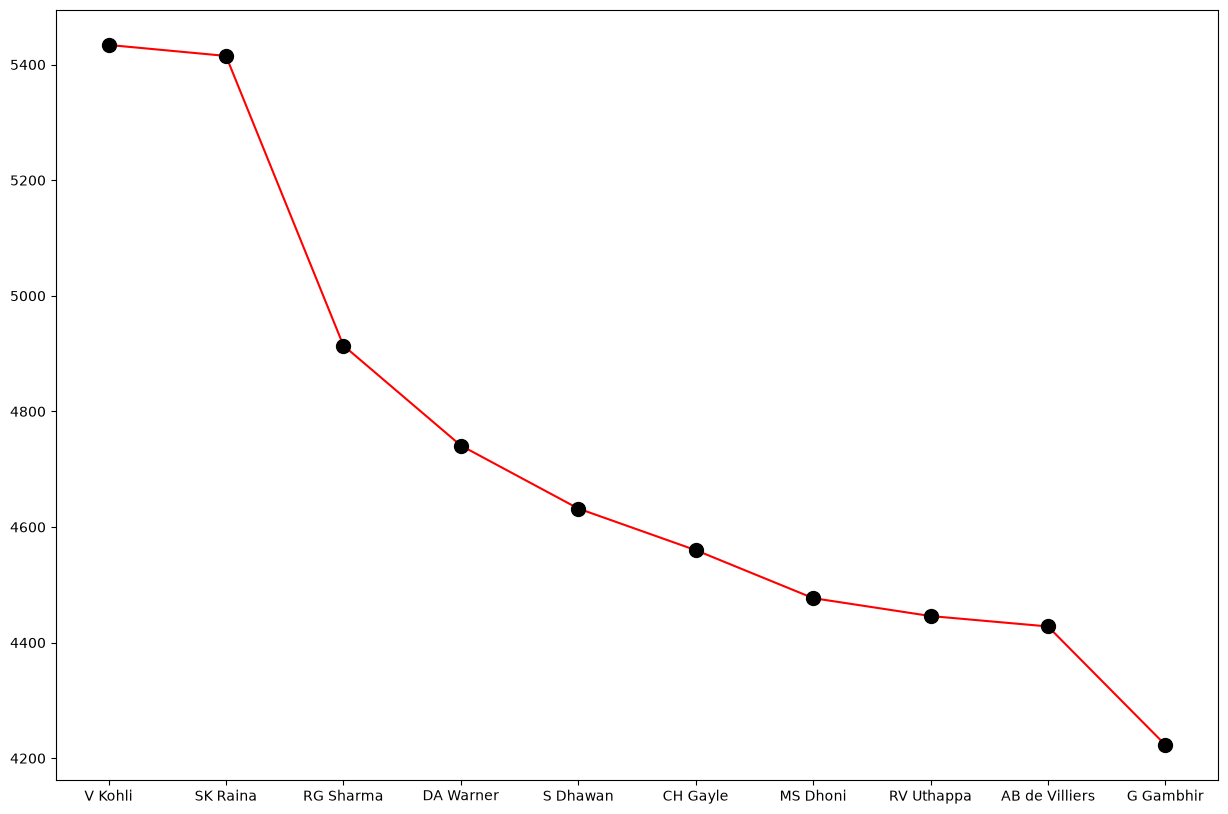

In [115]:
#Q10
import matplotlib.pyplot as plt
batsman_runs_list = df.groupby("batsman")["batsman_runs"].sum().reset_index(name="Total Runs scored by batsman").rename(columns={"batsman":"Player"})
top_batsman_runs_list = batsman_runs_list.nlargest(10,"Total Runs scored by batsman",keep = "all")
plt.figure(figsize=(15,10))
x=top_batsman_runs_list["Player"]
y=top_batsman_runs_list["Total Runs scored by batsman"]

plt.plot(x,y,marker=".",markersize=20,mfc="black",color="red",mec="Black")
plt.show()